In [15]:
import glob
import os
import polars as pl
import polars.selectors as cs
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from hta.trace_analysis import TraceAnalysis
from adjustText import adjust_text

power_labels = [
    "IBP,",        "ICP,",        "DCP,",      "TCP,",      "CCP,",
    "SHRDP,",      "RFP,",        "INTP,",     "FPUP,",     "DPUP,",
    "INT_MUL24P,", "INT_MUL32P,", "INT_MULP,", "INT_DIVP,", "FP_MULP,",
    "FP_DIVP,",    "FP_SQRTP,",   "FP_LGP,",   "FP_SINP,",  "FP_EXP,",
    "DP_MULP,",    "DP_DIVP,",    "TENSORP,",  "TEXP,",     "SCHEDP,",
    "L2CP,",       "MCP,",        "NOCP,",     "DRAMP,",    "PIPEP,",
    "IDLE_COREP,", "CONSTP",      "STATICP"
]

In [3]:
df = (
    pl.scan_csv(
        "/users/zarand1a/accel-sim-framework/sim_run_12.8/*/NO_ARGS/QV100-Accelwattch_SASS_SIM/accelwattch_power_report.log", 
        has_header=False, 
        separator="?", 
        include_file_paths="path",
    )
    .select(
        pl.col("path").str.extract(r"sim_run_12.8/([^/]*)/.*/accelwattch_power_report.log")
        .alias("model"),
        pl.col("column_1").alias("data")
    )
    .with_row_index()
    .collect()
)
power_df = (
    (
        df.filter(pl.col("data").str.starts_with("gpu_avg_"))
        .select(
            "index",
            pl.col("data")
            .str.replace("^gpu_avg_", "")
            .str.replace_all(" ", "")
            .str.splitn("=", 2)
            .struct.rename_fields(["label", "value"])
            .struct.with_fields(pl.field("value").cast(float))
            .struct.unnest()
        )
    )
    .join_asof(
        df.filter(pl.col("data").str.starts_with("kernel_name"))
        .select(
            pl.col("index"),
            pl.col("index").rank("dense").over("model").alias("serial"),
            pl.col("model"),
            pl.col("data").str.extract("kernel_name = (.*)").alias("kernel")
        ),
        on="index",
    )
    .drop("index")
    .group_by("model", "serial", "kernel", "label").agg(pl.mean("value"))
    .pivot(on="label", index=["model", "serial", "kernel"])
    .select("model", "serial", "kernel", *power_labels)
    .with_columns(
        pl.col("DRAMP,") + pl.col("MCP,"),
        pl.col("L2CP,") + pl.col("NOCP,"),
    )
    .rename(lambda col: col.replace(",", ""))
    .unpivot(index=["model", "serial", "kernel"], value_name="power_w")
    .group_by("model", "serial", "kernel")
    .agg(pl.sum("power_w"))
    .sort("model", "serial", "kernel")
)
df = (
    pl.scan_csv("/users/zarand1a/accel-sim-framework/sim_run_12.8/*/NO_ARGS/QV100-Accelwattch_SASS_SIM/*-NO_ARGS.*",
        has_header=False, 
        separator="&", 
        include_file_paths="path",
    )
    .select(
        pl.col("path").str.extract(r"sim_run_12.8/([^/]*)/.*")
        .alias("model"),
        pl.col("column_1").alias("data")
    )
    .with_row_index()
    .collect()
)
cycle_df = (
    df.filter(pl.col("data").str.starts_with("kernel_name ="))
    .select(
        "index", "model",
        pl.col("data").str.extract("kernel_name = (.*)").alias("kernel"),
    )
).join(
    df.filter(pl.col("data").str.starts_with("gpu_sim_cycle ="))
    .select(
        pl.col("index") - 3,
        pl.col("data").str.extract("gpu_sim_cycle = (.*)").cast(int).alias("cycle"),
    ),
    on="index",
).select(
    "model",
    pl.col("index").rank("dense").over("model").alias("serial"),
    "kernel", "cycle",
)
accel_df = (
    power_df.join(cycle_df, on=["model", "serial", "kernel"])
    .filter(pl.col("power_w").is_not_nan())
    .group_by("model")
    .agg(
        power_w=(pl.col("power_w") * pl.col("cycle")).sum() / pl.col("cycle").sum()
    )
)
df = (
    pl.scan_csv(
        "/proj/threadtune-PG0/amir/power_logs/*-power.0.csv", 
        include_file_paths="path",
    )
    .with_columns(
        pl.col("path").str.extract(r"/proj/threadtune-PG0/amir/power_logs/(.*)-power.0.csv")
        .alias("model"),
    )
    .drop("path")
    .collect()
)
measure_df = (
    df.sort("timestamp_ns")
    .group_by("model")
    .agg(
        power_w=(
            pl.col("total_energy_millijoules").max() - pl.col("total_energy_millijoules").min()
        ) / (
            pl.col("timestamp_ns").max() - pl.col("timestamp_ns").min()
        ) * 1e6,
        measured_uncertainty=(
            pl.col("total_energy_millijoules").diff() / pl.col("timestamp_ns").diff() * 1e6
        ).std()
    )
)
sim_real_df = (
    accel_df.rename({"power_w": "sim_power_w"})
    .join(
        measure_df.rename({"power_w": "measured_power_w"}), 
        on="model"
    )
)

In [4]:
trace_root = "/proj/threadtune-PG0/amir/kineto_traces/"
idle_dfs = []

for trace_path in glob.glob(os.path.join(trace_root, "*")):
    bench = os.path.basename(trace_path)
    analyzer = TraceAnalysis(trace_files={0: os.path.join(trace_path, "device.0.json")})
            
    breakdown = analyzer.get_temporal_breakdown(visualize=False)
            
    if 0 in breakdown.index:
        idle_us = breakdown.loc[0, "idle_time(us)"]
        compute_us = breakdown.loc[0, "compute_time(us)"]
        non_compute_us = breakdown.loc[0, "non_compute_time(us)"]
        
        total_time_us = idle_us + compute_us + non_compute_us
        idle_pct = (idle_us / total_time_us) * 100 if total_time_us > 0 else 0
        
        current_df = pl.DataFrame({
            "path": [trace_path],
            "idle_pct": [idle_pct],
            "total_time_s": [total_time_us / 1e6]
        })
        
        idle_dfs.append(current_df)
    
    idle_df = (
        pl.concat(idle_dfs)
        .with_columns(
            pl.col("path")
            .str.extract(r"/([^/]*)$")
            .str.replace("-inference", "")
            .alias("model")
        )
        .drop("path")
    )
    
idle_df



Parsed /proj/threadtune-PG0/amir/kineto_traces/deit-train/device.0.json time = 0.29 seconds 
Rounding down ns resolution events due to issue with events overlapping. ts dtype = float64, dur dtype = float64.Please see https://github.com/pytorch/pytorch/pull/122425
Parsed /proj/threadtune-PG0/amir/kineto_traces/deit-train/device.0.json backend=json in 0.60 seconds; current PID:147468
Overall parsing of /proj/threadtune-PG0/amir/kineto_traces/deit-train/device.0.json in 0.67 seconds; current PID:147468
leaving parse_multiple_ranks duration=0.68 seconds
leaving parse_traces duration=0.68 seconds
There is only one iteration in the trace. The analysis result may not be accurate.
Parsed /proj/threadtune-PG0/amir/kineto_traces/gpt2-inference/device.0.json time = 0.19 seconds 
Rounding down ns resolution events due to issue with events overlapping. ts dtype = float64, dur dtype = float64.Please see https://github.com/pytorch/pytorch/pull/122425
Parsed /proj/threadtune-PG0/amir/kineto_traces/gpt

idle_pct,total_time_s,model
f64,f64,str
97.945031,0.556456,"""deit-train"""
99.187793,0.36013,"""gpt2"""
90.707716,0.329779,"""bloom-train"""
98.172705,0.593117,"""resnet50-train"""
95.174009,0.476068,"""gpt2-train"""
…,…,…
98.948947,0.15337,"""bert"""
98.649641,0.215202,"""deit"""
98.974316,0.454331,"""bloom"""


In [5]:
final_df = (
    sim_real_df
    .join(idle_df, on="model", how="inner")
    .with_columns(
        (pl.col("sim_power_w") - pl.col("measured_power_w")).alias("error_w")
    )
)
final_df

model,sim_power_w,measured_power_w,measured_uncertainty,idle_pct,total_time_s,error_w
str,f64,f64,f64,f64,f64,f64
"""deit-train""",97.265104,68.242799,3.031004,97.945031,0.556456,29.022305
"""gpt2""",92.793675,38.570944,0.419324,99.187793,0.36013,54.22273
"""resnet50-train""",98.370075,70.123221,3.523451,98.172705,0.593117,28.246854
"""resnet50""",92.827203,54.032302,1.207256,99.039769,0.276496,38.794901
"""bert""",96.99283,59.101363,0.714305,98.948947,0.15337,37.891467
"""deit""",91.044472,54.731851,1.556623,98.649641,0.215202,36.312622
"""bloom""",112.715731,74.344924,2.042127,98.974316,0.454331,38.370807
"""gemma""",118.201962,107.656783,4.907304,97.192972,0.398286,10.545179


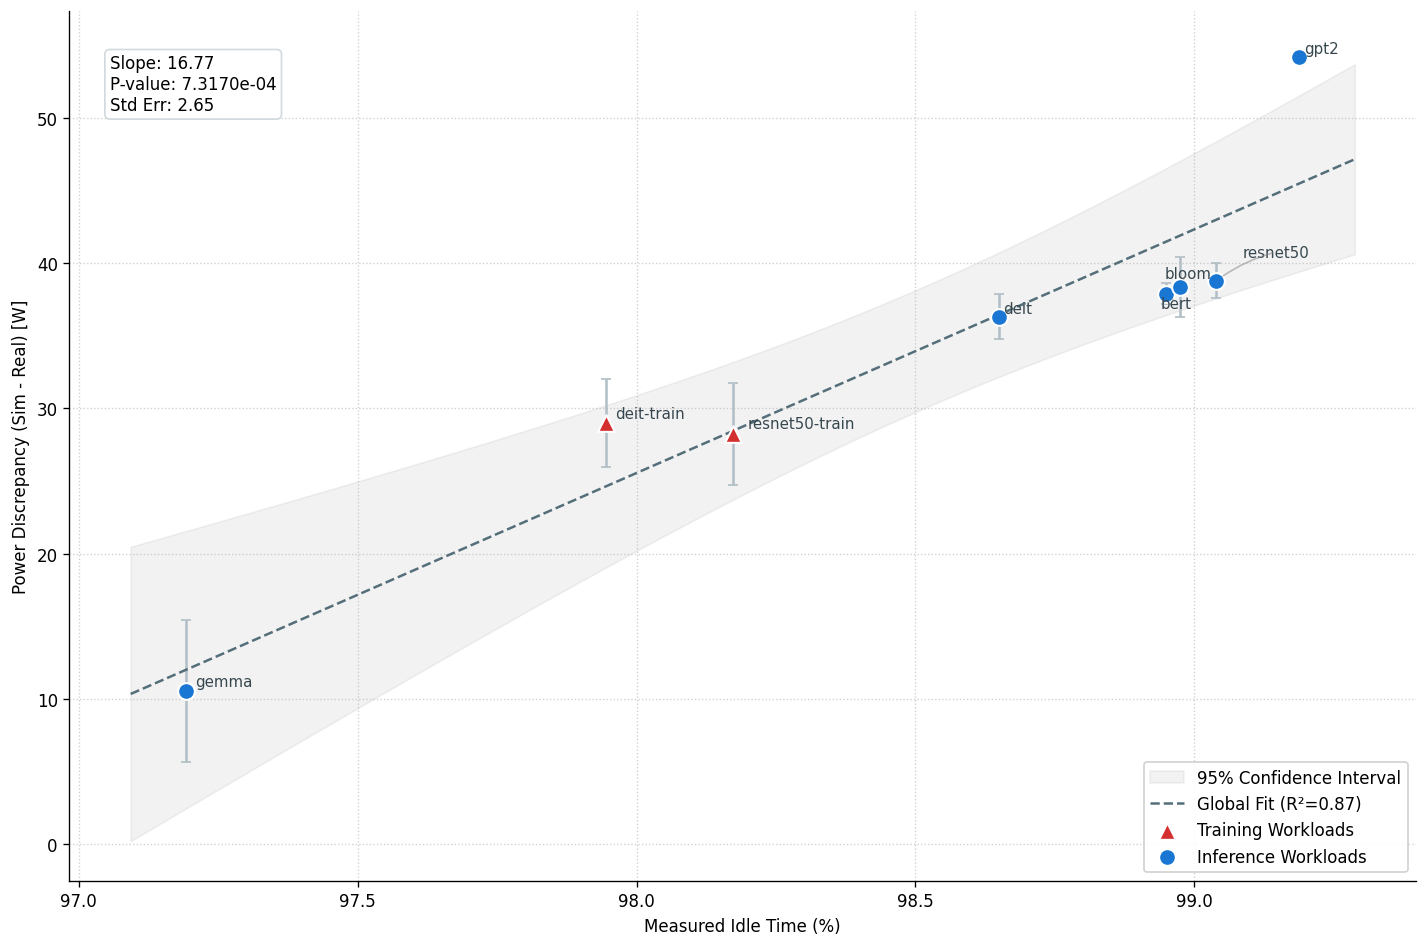

In [39]:
pdf = final_df.to_pandas()

pdf['type'] = pdf['model'].apply(lambda x: 'Training' if 'train' in x.lower() else 'Inference')

slope, intercept, r_value, p_value, std_err = stats.linregress(pdf["idle_pct"], pdf["error_w"])

x_vals = np.linspace(pdf["idle_pct"].min() - 0.1, pdf["idle_pct"].max() + 0.1, 100)
y_vals = slope * x_vals + intercept

n = len(pdf)
t_score = stats.t.ppf(0.975, df=n-2)
s_err = np.sqrt(np.sum((pdf["error_w"] - (slope * pdf["idle_pct"] + intercept))**2) / (n - 2))
ci = t_score * s_err * np.sqrt(1/n + (x_vals - np.mean(pdf["idle_pct"]))**2 / np.sum((pdf["idle_pct"] - np.mean(pdf["idle_pct"]))**2))

fig, ax = plt.subplots(figsize=(12, 8), dpi=120)
ax.fill_between(x_vals, (y_vals - ci), (y_vals + ci), color='gray', alpha=0.1, label='95% Confidence Interval')
line_plot, = ax.plot(x_vals, y_vals, color='#546E7A', linestyle='--', linewidth=1.5, label=f'Global Fit (R²={r_value**2:.2f})')

eb = ax.errorbar(
    pdf["idle_pct"], pdf["error_w"], 
    yerr=pdf["measured_uncertainty"], 
    fmt='none', ecolor='#B0BEC5', elinewidth=1.5, capsize=3, zorder=1
)

scatter_objects = [] 
styles = {
    'Training':  {'color': '#D32F2F', 'marker': '^', 'label': 'Training Workloads'}, 
    'Inference': {'color': '#1976D2', 'marker': 'o', 'label': 'Inference Workloads'} 
}

for w_type, style in styles.items():
    subset = pdf[pdf['type'] == w_type]
    sc = ax.scatter(
        subset["idle_pct"], subset["error_w"],
        c=style['color'],
        marker=style['marker'],
        s=100,
        edgecolor='white',
        linewidth=1.2,
        label=style['label'],
        zorder=2
    )
    scatter_objects.append(sc)

lines_list = [line_plot] if not isinstance(line_plot, list) else line_plot

objects_to_avoid = lines_list + scatter_objects + list(eb[2])

texts = []
for i, row in pdf.iterrows():
    texts.append(ax.text(row['idle_pct'], row['error_w'], row['model'], color='#37474F', fontsize=9))

adjust_text(
    texts,
    ax=ax,
    add_objects=objects_to_avoid,
    only_move={'points':'xy', 'text':'xy', 'objects':'xy'},
    force_text=(7, 8),  
    force_points=(5, 8),
    force_objects=(5, 8),
    expand_points=(15, 15), 
    expand_text=(12, 12),
    expand_objects=(12, 12),
    lim=100000,
    arrowprops=dict(
        arrowstyle='-', 
        color='gray', 
        alpha=0.5, 
        lw=1.0,
        shrinkB=5,
        connectionstyle="arc3,rad=0.1" 
    )
)

stats_text = (
    f"Slope: {slope:.2f}\n"
    f"P-value: {p_value:.4e}\n"
    f"Std Err: {std_err:.2f}"
)
props = dict(boxstyle='round', facecolor='white', alpha=0.95, edgecolor='#CFD8DC')
ax.text(0.03, 0.95, stats_text, transform=ax.transAxes, verticalalignment='top', bbox=props)

ax.set_xlabel("Measured Idle Time (%)")
ax.set_ylabel("Power Discrepancy (Sim - Real) [W]")

ax.grid(True, linestyle=':', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(loc='lower right', frameon=True, fancybox=True, framealpha=0.9)

plt.tight_layout()
plt.savefig("validation_by_model_type.png")
plt.show()